In [ ]:

!pip install timm

import torch
import cv2
import matplotlib.pyplot as plt

# MiDaS 모델 로드
print("인텔 연구소에서 MiDaS 모델을 다운로드하는 중... ⏳")

midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", trust_repo=True)
midas.eval()

print("MiDaS 모델 세팅 완료")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
인텔 연구소에서 MiDaS 모델을 다운로드하는 중... ⏳


Using cache found in /Users/arago/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /Users/arago/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


🎉 MiDaS 모델 세팅 완료! 내 PC가 3D 공간을 인식할 준비가 끝났습니다.


Using cache found in /Users/arago/.cache/torch/hub/intel-isl_MiDaS_master


image의 3D 공간을 계산하는 중...


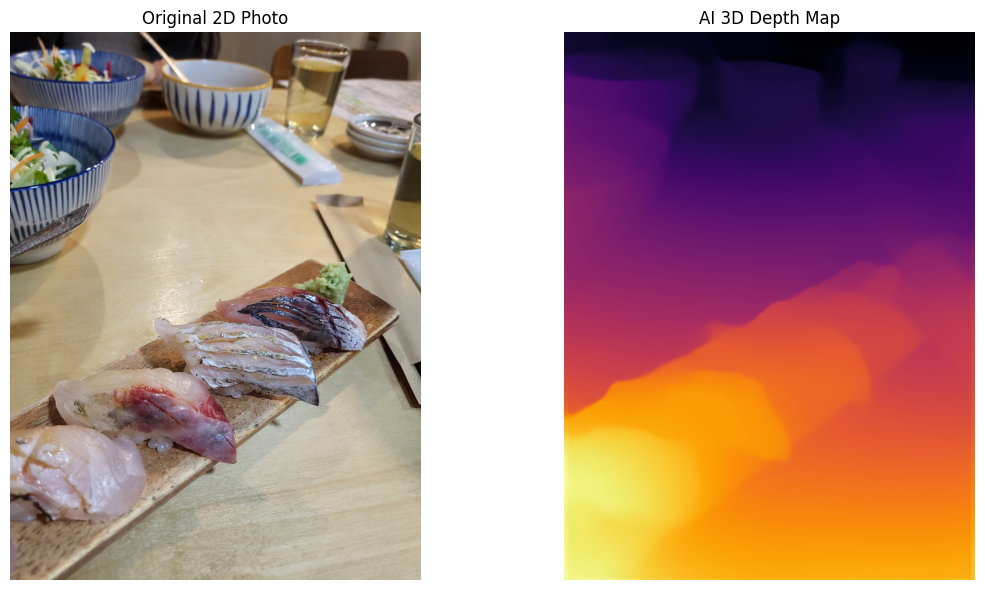

✨ 짠! 2D 사진에서 3D 공간을 뽑아냈습니다!


In [ ]:
# 1. 모델이 인식할 수 있는 크기로 이미지를 조정하기 위한 준비
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms", trust_repo=True) # size=256*256
transform = midas_transforms.small_transform

# 2. 사진 준비
img_path = "../images/3d_vision/my_photo.jpeg"
img = cv2.imread(img_path) # reading images
# to convert colors(OpenCV: BGR) -> (Human Eyes: RGB)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

# 3. 사진 전처리(Resize + ToTensor(type: ndarray -> tensor) + Batching + Normalizatioin)
input_batch = transform(img)

# 4. Prediction using AI
print("image의 3D 공간을 계산하는 중...")
with torch.no_grad(): # 학습 x
    prediction = midas(input_batch)

    # 원래 사진 크기로 다시 늘려주기
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1), # put fake dimension to calculate
        size=img.shape[:2], # [H, W]
        mode="bicubic", # image 깨짐 방지를 위해 부드럽게
        align_corners=False, # bicubic 사용시 'false'
    ).squeeze()

# 5. 결과 시각화하기 (L: Original, R: 3D Depth Map)
output = prediction.cpu().numpy()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original 2D Photo")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("AI 3D Depth Map")
# 가까운 것: brightly, 먼 것: darkly - (Inferno Colormap)
plt.imshow(output, cmap='inferno') 
plt.axis('off')

plt.tight_layout()
plt.show()
print("2D 사진에서 3D 공간을 뽑아내기 성공!")

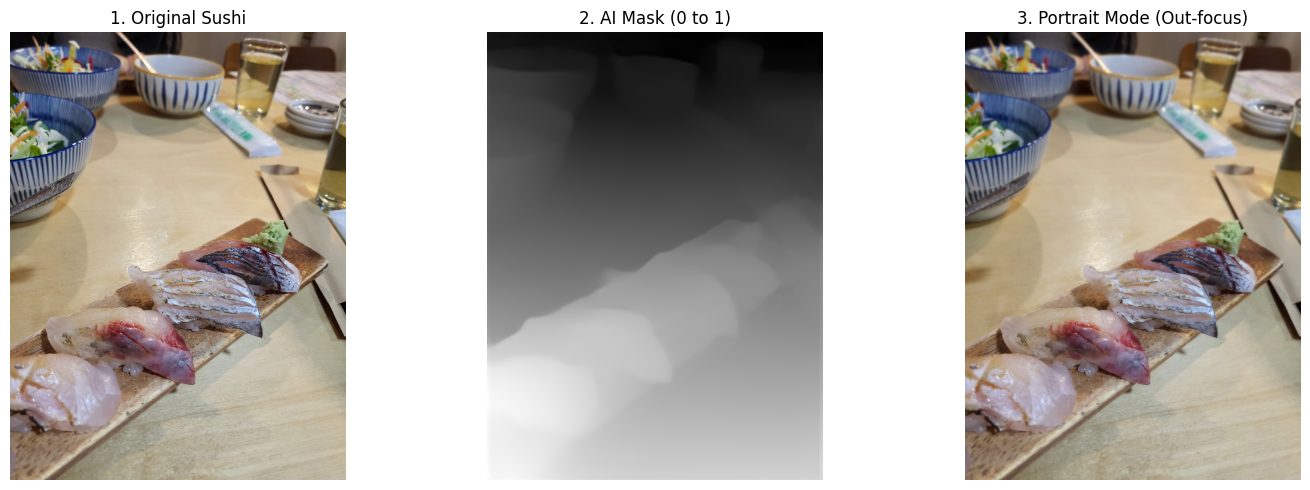

완성!


In [ ]:
import numpy as np

# 1. 마스크 행렬(M) 만들기: depth map 정규화 with Min-Max Scaling
depth_min = output.min()
depth_max = output.max()
mask = (output - depth_min) / (depth_max - depth_min)

# 마스크: 흑백(2차원), 원본 사진: RGB(3차원)
# 행렬 곱셈을 위해 마스크의 차원을 강제로 늘리기
mask_3d = np.expand_dims(mask, axis=-1)  # [세로, 가로] -> [세로, 가로, 1]
mask_3d = np.repeat(mask_3d, 3, axis=-1) # [세로, 가로, 1] -> [세로, 가로, 3]으로 차원 불리기

# 2. To generate blurry background(by Gaussian Blur)
# 뭉개는 강도: 홀수이며 숫자가 커질수록 더 흐림. 결과의 가시성을 위해 (51, 51) -> (71, 71)로 조정
blur_img = cv2.GaussianBlur(img, (71, 71), 0) # cv가 optimal sd(standard deviation) 계산

# 3. Alpha Blending : 이미지 겹치기
portrait_img = (mask_3d * img + (1 - mask_3d) * blur_img)

# 계산이 끝난 행렬을 다시 0~255 정수(uint8)로 조정
portrait_img = portrait_img.astype(np.uint8)

# 4. 결과 시각화
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("1. Original Sushi")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. AI Mask (0 to 1)")
plt.imshow(mask, cmap='gray') # 흑백
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Portrait Mode (Out-focus)")
plt.imshow(portrait_img)
plt.axis('off')

plt.tight_layout()
plt.show()
print("완성!")